# Cox-BNN
## A Bayesian Neural Network for Sruvival Analysis

**Authors**: Alice Conighi, Emanuele Valea, Giovanni Zedda

<small>Final project for Probabilistic and Machine Learning course held by Prof. Luca Bortolussi at University of Trieste A.Y. 2025/2026.</small>


### Introduction

In this project we are going to do some experiments on a Bayesian Neural Network for survival data. With survival data we refer to time-to-event modelling, usually in presence of censoring, which means that not all instances are observed until the occurence of the event.

More formally, we deal with data $(T_i, \Delta_i)$, where $T_i=\min(Y_i, C_i)$, minimum between the real time-to-event $Y_i$ and time to censoring $C_i$, and $\Delta_i=I(Y_i\le C_i)$. Notice that $\Delta_i=0$ does not refer to a missing datum, because it conveys anyway the valuable information that subject $i$ was "alive" at least up to time $C_i$.

For a theoretical introduction to basic quantities and definitions in survival analysis, we point the `EDA_and_CoxModel.ipynb` file or - even better - to Klein and Moeschberger (2003).

We use only a dataset for testing the methods we propose, but Lillelund, Magris and Pedersen (2024) show interesting results for a more variegate benchmark. The dataset we use comes from the National Institutes of Health and comprehends a list of 2139 subjects who are infected with HIV. The time-to-event here is the occurence an AIDS defining symptom or the halving of CD4 or both. Or death.

The censoring mechanism is a bit more complicated than raw right-censoring, however we stick to the latter. Censoring is also reasonably independent from the real time-to-event, since it is mostly a constant (Type 1 censoring, the end of study).


### Dataset

In [1]:
from ucimlrepo import list_available_datasets, fetch_ucirepo
list_available_datasets(search='AIDS')

-------------------------------------------------------------
The following datasets are available for search query "aids":
-------------------------------------------------------------
Dataset Name                            ID    
------------                            --    
AIDS Clinical Trials Group Study 175    890   



In [2]:
aids_clinical_trials_group = fetch_ucirepo(id=890) 
print(aids_clinical_trials_group.keys())

dict_keys(['data', 'metadata', 'variables'])


In [3]:
aids_clinical_trials_group.variables

,name,role,type,demographic,description,units,missing_values
0,pidnum,ID,Integer,None,Patient ID,None,no
1,cid,Target,Binary,None,"censoring indicator (1 = failure, 0 = censoring)",None,no
2,time,Feature,Integer,None,time to failure or censoring,None,no
3,trt,Feature,Integer,None,treatment indicator (0 = ZDV only; 1 = ZDV + d...,None,no
4,age,Feature,Integer,Age,age (yrs) at baseline,None,no
5,wtkg,Feature,Continuous,None,weight (kg) at baseline,None,no
6,hemo,Feature,Binary,None,"hemophilia (0=no, 1=yes)",None,no
7,homo,Feature,Binary,Sexual Orientation,"homosexual activity (0=no, 1=yes)",None,no
8,drugs,Feature,Binary,None,"history of IV drug use (0=no, 1=yes)",None,no
9,karnof,Feature,Integer,None,Karnofsky score (on a scale of 0-100),None,no


### Exploratory Data Analysis and Preprocessing

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
assert aids_clinical_trials_group.data is not None, "No data found"
aids: pd.DataFrame = pd.concat([
        aids_clinical_trials_group.data['features'], 
        aids_clinical_trials_group.data['targets']
    ], axis=1
)

In [6]:
pd.options.display.max_columns = None
display(aids.head())

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [7]:
print('Total number of observations:', len(aids))
print(f"Total number of complete observations: {aids.cid.sum()} ({100*aids.cid.mean():.2f}%)")

Total number of observations: 2139
Total number of complete observations: 521 (24.36%)


In [8]:
aids.std()[aids.std()<0.2]

oprior    0.146629
zprior    0.000000
dtype: float64

Variable `zprior` show no variability in the dataset, hence we will remove it later. Below we show a boxplot to evidentiate the survival time difference between the four treatments. Further plots are not necessary to the scope by now.

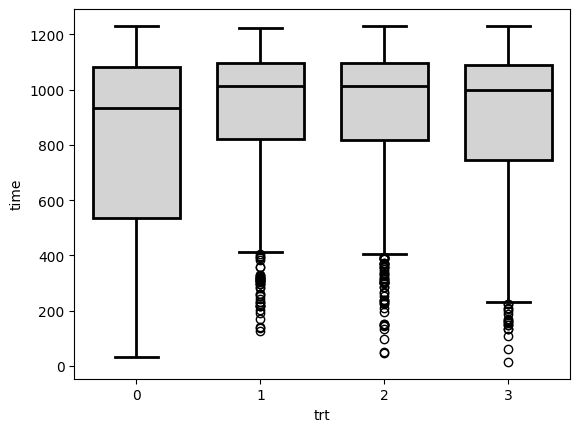

In [9]:
sns.boxplot(data=aids, x='trt', y='time', color='lightgrey', 
            linecolor='black', linewidth=2, width=0.7)#, ax=axes[0])
plt.show()

In [10]:
aids.groupby('strat')[['preanti']].mean()
# strat:
    # antiretroviral history stratification (1='Antiretroviral Naive',
    #                                        2='> 1 but <= 52 weeks of prior antiretroviral therapy',
    #                                        3='> 52 weeks)
# preanti:
    # days pre-175 anti-retroviral therapy

,preanti
strat,
1,0.081264
2,186.890244
3,871.126928


### Model and Loss function

We use a Bayesian Neural Network, a Feedforward Multilayer Perceptron whose weights contain "epistemic" uncertainty, i.e., they are random variables, of which we approximate the posterior via mean field Variational Inference. 

For the variational inference approach, we need a prior, a likelihood and a variational distribution that approximates the posterior.
- $p(\bm w)$ - the prior - is assumed to be multivariate normal, with independence between nodes. 
- $q_\theta(\bm w)$ - the variational approximation - is set normal, $\theta=(\bm \mu, \bm\sigma)$. Both $p(\bm w)$ and $q_\theta(\bm w)$ could be more or less easily generalized to other distributions, such as Laplace distribution or multivariate normal within a layer.
- $p(\mathbf t |\bm w)$ - the likelihood - is the partial likelihood of a Cox model. 
Let $f(\bm w, \bm x_i)$ be the (random) output of the neural network. The model is defined as $$h(t|\bm x_i)=h_0(t)\exp{(f(\bm w, \bm x_i))}$$
from which we can extract a log partial likelihood for the parameters of interest which is
$$\log p(\mathbf t|\bm w)=\sum_{i:\delta_i=1}f(\bm w, \bm x_i)-\sum_{i:\delta_i=1}\log\sum_{j: t_j\ge t_i}\exp f(\bm w, \bm x_j) + C.$$
Proportionality of risks is actually the strongest assumption we make in our model.

Hence, we derive the formula for the evidence lower bound
$$ELBO = \mathbb E_{q_\theta(\bm w)}\left[\log p(\mathbf t|\bm w, \mathbf X)+\log p(\bm w)-\log q_\theta(\bm w)\right]$$
which we want to maximize, i.e., minimize the negative:
$$\mathcal L(\theta)=-{\mathbb E}_q[\log p(\mathbf t|\bm w, \mathbf X)] + KL({q_\theta}(\bm w)\|p(\bm w))$$

The first term is the Cox partial likelihood (constant does not matter), the second term is a "regularization" term that is the Kullback-Leibler divergence between the variational posterior and the prior, that for independent normal random variables is the sum of the following contributions 
$$
\mathrm{KL}[q \| p] = \log\frac{\sigma_0}{\sigma} + \frac{\sigma^2 + \mu^2}{2\sigma_0^2} - \frac{1}{2}.
$$

In this model, the survival function can be retrieved as $S(t|\bm x_i)=S_0(t)^{\exp{(f(\bm w, \bm x_i))}}$, where $S_0(t)=\exp{-H_0(t)}$, $H_0(t)=\int_0^t h_0(u)du$, the latter called cumulative hazard function.

Hyperparameters of this network will be tuned separately later.

In [11]:
from collections import OrderedDict
from itertools import pairwise
from typing import Any, Callable, Sequence, Sized

import torch
import torch.nn as nn
import torch.nn.functional as F

In [12]:
class BayesianGaussianLinear(nn.Module):
    """
    Parameters: mu_w, rho_w (weights), mu_b, rho_b (biases).
    sigma = softplus(rho) ensures positivity without constraints.
    """
    def __init__(self, in_dim: int, out_dim: int, prior_sigma: float = 2.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.prior_sigma  = prior_sigma

        kaiming_he_sigma = 4/(in_dim+out_dim)

        # Variational parameters for weights: shape (out, in)
        self.mu_w = nn.Parameter(torch.empty(out_dim, in_dim).normal_(0, kaiming_he_sigma))
        self.rho_w = nn.Parameter(torch.empty(out_dim, in_dim).fill_(-2.5))

        # Variational parameters for biases: shape (out,)
        self.mu_b = nn.Parameter(torch.empty(out_dim).normal_(0, 0.1))
        self.rho_b = nn.Parameter(torch.empty(out_dim).fill_(-2.5))


    def _sigma(self, rho: nn.Parameter):
        """Softplus riparametrization."""
        sigma = F.softplus(rho) + 1e-8
        return sigma


    def _kl_gaussian(self, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        """KL Divergence (closed formula) between prior and 
        variational posterior with mean field assumption.
        """
        sigma0 = self.prior_sigma
        kl = (torch.log(sigma0/sigma) + (sigma**2 + mu**2) / (2*sigma0**2) - 1/2).sum()
        return kl
    

    def layer_kl(self) -> torch.Tensor:
        "Compute the KL regularization term for a single layer."
        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        return(
            self._kl_gaussian(self.mu_w, sigma_w) 
            + self._kl_gaussian(self.mu_b, sigma_b)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x has size (B, nodes)

        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        # Reparametrization
        eps_w = torch.randn_like(self.mu_w)
        eps_b = torch.randn_like(self.mu_b)
        W = sigma_w*eps_w + self.mu_w
        b  = sigma_b*eps_b + self.mu_b

        # Standard linear transformation
        out = x @ W.T + b

        # KL contribution from this layer
        # kl = self._kl_gaussian(self.mu_w, sigma_w) + self._kl_gaussian(self.mu_b, sigma_b)

        return out

In [13]:
class BayesianGaussianMultivariate(nn.Module):
    """
    Variant with full covariance for weights (suitable for small layers / last layer).
    Prior: N(0, sigma0^2 * I).
    Posterior: N(mu_w, Sigma_w) with Sigma_w = L @ L.T (Cholesky), plus mean-field bias.

    KL(N(mu, Sigma) || N(0, sigma0^2 I)) = 1/2 * [log(sigma0^{2n} / |Sigma|) + Tr(Sigma) / sigma0^2 + mu^T mu / sigma0^2 - n]
    """
    def __init__(self, in_dim: int, out_dim: int, prior_sigma: float = 2.0):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.prior_sigma = prior_sigma

        kaiming_he_sigma = 4/(in_dim+out_dim)
        n = out_dim * in_dim
                
        # Variational parameters for weights: shape (out, in)
        self.mu_w = nn.Parameter(torch.empty(out_dim, in_dim).normal_(0, kaiming_he_sigma))
        # Lower-triangular Cholesky factor of Sigma_w: shape (n, n)
        # Initialized as a small diagonal to stay close to the prior
        L_init = torch.eye(n) * 0.1
        self.L_w = nn.Parameter(L_init)

        # Variational parameters for biases: shape (out,)
        self.mu_b = nn.Parameter(torch.empty(out_dim).normal_(0, 0.1))
        self.rho_b = nn.Parameter(torch.empty(out_dim).fill_(-2.5))

    def _sigma(self, rho: nn.Parameter):
        """Softplus riparametrization."""
        sigma = F.softplus(rho) + 1e-8
        return sigma

    def _kl_gaussian(self, mu, sigma):
        """KL Divergence (closed formula) between prior and 
        variational posterior with mean field assumption.
        """
        sigma0 = self.prior_sigma
        kl = (torch.log(sigma0/sigma) + (sigma**2 + mu**2) / (2*sigma0**2) - 1/2).sum()
        return kl

    def _kl_gaussian_full(self) -> torch.Tensor:
        """
        Full-covariance KL divergence (closed form) between N(mu_w, Sigma_w) and the prior N(0, sigma0^2 I).
        Sigma_w = L @ L.T  (Cholesky decomposition guarantees SPD)

        KL(N(mu, Sigma) || N(0, sigma0^2 I)) = 1/2 * [log(sigma0^{2n} / |Sigma|) + Tr(Sigma) / sigma0^2 + mu^T mu / sigma0^2 - n]
        
        log|Sigma_w| = log|L L^T| = 2 * sum(log|diag(L)|)
        Tr(Sigma_w)  = ||L||_F^2  (since Tr(LL^T) = sum L_ij^2)
        """
        n = self.mu_w.numel()                                   # total number of weights
        sigma0 = self.prior_sigma                               # prior standard deviation
        L = self.L_w.tril()                                     # enforce lower-triangular structure on L
        diag_L = L.diagonal().abs().clamp(min=1e-8)             # absolute value of L's diagonal, clamped for numerical stability
        log_det_Sigma = 2.0 * diag_L.log().sum()                # log|Sigma| = log|LL^T| = 2 * sum(log|diag(L)|)
        trace_term = (L ** 2).sum() / (sigma0 ** 2)             # Tr(Sigma) / sigma0^2 = ||L||_F^2 / sigma0^2
        quad_term = (self.mu_w ** 2).sum() / (sigma0 ** 2)      # mu^T mu / sigma0^2
        
        # KL = 1/2 * [n*log(sigma0^2) - log|Sigma| + Tr(Sigma)/sigma0^2 + mu^T mu/sigma0^2 - n]
        kl = 0.5 * (n * 2 * torch.log(torch.tensor(sigma0)) - log_det_Sigma + trace_term + quad_term - n)
        return kl

    def layer_kl(self) -> torch.Tensor:
        """KL divergence between the prior and 
        the variational posterior within the layer.
        """
        sigma_b = self._sigma(self.rho_b)
        return(
            self._kl_gaussian_full() 
            + self._kl_gaussian(self.mu_b, sigma_b))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x has size (B, in_dim)

        n = self.mu_w.numel()
        L = self.L_w.tril()

        # Reparametrization trick: w_flat = mu_flat + L @ eps,  eps ~ N(0, I)
        eps_w = torch.randn(n, device=x.device)
        w_flat = self.mu_w.view(-1) + L @ eps_w
        W = w_flat.view(self.out_dim, self.in_dim)

        # Softplus transformation + reparametrization for biases
        sigma_b = self._sigma(self.rho_b)
        eps_b = torch.randn_like(self.mu_b)
        b = self.mu_b + sigma_b * eps_b

        # Standard linear transformation
        out = x @ W.T + b

        return out

In [14]:
class BayesianMLP(nn.Module):
    def __init__(self, *size: int, prior_sigma: float = 1.0):
        if len(size) < 1:
            raise ValueError('At least one size (input size) must be provided')
        super().__init__()
        self.size = size
        self.prior_sigma = prior_sigma
        self.net = self.__make_net()

    def __make_net(self) -> nn.Sequential:
        layers: list[tuple[str, nn.Module]] = []
        for k, (s_in, s_out) in enumerate(pairwise(self.size[:-1])):
            layers.append((f"l{k}", BayesianGaussianLinear(s_in, s_out, self.prior_sigma)))
            layers.append((f"h{k}", nn.Tanh()))
        layers.append(('out', BayesianGaussianMultivariate(self.size[-2], self.size[-1], self.prior_sigma)))
        return nn.Sequential(OrderedDict(layers))

    def network_kl(self) -> torch.Tensor:
        """Sum over all KL contributions in the layers."""
        kl = torch.tensor(0.0, dtype=torch.float)
        for layer in self.net:
            if hasattr(layer, 'layer_kl') and isinstance(layer.layer_kl, Callable):
                kl += layer.layer_kl()
        return kl

    def forward(self, x):
        return self.net(x)

In [15]:
def cox_partial_loglik(t: torch.Tensor, 
                       delta: torch.Tensor, 
                       loghr_hat: torch.Tensor) -> torch.Tensor:
    """Cox Partial Likelihood (the negative is a loss component)

    Parameters
    ----------
    t : Tensor[float]
        Time to event or censoring
    delta : Tensor[float]
        Indicator `1.0` is observed
    loghr_hat : Tensor[float]
        Output of the BNN
    
    All inputs must be reduced to size (BATCH_SIZE,).
    
    Returns
    -------
    ll : ScalarTensor
        The partial log-likelihood for a Cox proportional hazards model
        with Breslow tie-breaker.

        Sum_{i: delta_i==1} [h - log Sum_{j: t_j>=t_i} exp(h)]

        h output of the neural network.
    """
    assert len(t.shape) == len(delta.shape) == len(loghr_hat.shape) == 1, "All inputs must be reduced to size (BATCH_SIZE,)"
    hr_hat = torch.exp(loghr_hat)
    riskset = t.view(-1, 1) <= t.repeat(len(t), 1) 
        # boolean matrix where the `i`-th row denotes the
        # risk set of the `i`-th instance, i.e. the indices `j`
        # for which the observer time `y_j >= y_i`.

    # ll = loghr_hat.where(delta>0, 0.0).sum()
    # for t_i in t[delta>0]:
    #     ll -= torch.log(
    #         hr_hat.where(t>=t_i, 0.0).sum()
    #     )

    log_denominator = torch.log(
        (riskset*hr_hat.repeat(len(hr_hat), 1)).sum(dim=1)
    )
    ll = ((delta > 0) * (loghr_hat - log_denominator)).sum()

    return ll


def cox_elbo_loss(t: torch.Tensor,
              delta: torch.Tensor,
              loghr_hat: torch.Tensor,
              kl: torch.Tensor):
    """Negative partial lok-likelihood + KL(q(theta) || p(theta))"""
    assert t.shape == delta.shape == loghr_hat.shape, "Tensor sizes must match."
    batch_size = len(t)
    # kl_weight = batch_size / N
    nll = -cox_partial_loglik(t, delta, loghr_hat)
    return nll + kl


## Training

The presence of this costum loss function which has a quadratic complexity in the evaluation may be a major bottleneck, but it is still manageable for this medium-small dataset, unless we do intensive hyper-parameter validation. There could be some tricks to decrease the training time, e.g., computing the riskset once and then accessing the rows we need during training, but the overall computational complexity is the same, so we stick to our basic implementation. The optimizer we use is Adam with a fixed learning rate of 0.001.  

In [16]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim

In [17]:
from helpers import StandardScaler
scaler = StandardScaler()
design_matrix = torch.tensor(
    pd.get_dummies(
        aids.drop(columns=['time', 'zprior', 'cid']),
        columns=['trt'],
        dtype=np.float64
    ).values,
    dtype = torch.float
)

design_matrix = scaler.fit_transform(design_matrix)
design_matrix


tensor([[ 1.4642,  1.1074, -0.3031,  ..., -0.5680,  1.7552, -0.5961],
        [ 2.9569, -1.9364, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        [ 1.1197,  1.0048, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        ...,
        [ 2.0383, -0.3974,  3.2982,  ..., -0.5680,  1.7552, -0.5961],
        [-2.4398, -1.1404,  3.2982,  ..., -0.5680, -0.5695, -0.5961],
        [ 1.1197,  0.1640,  3.2982,  ..., -0.5680, -0.5695,  1.6768]])

In [18]:
time = torch.tensor(aids.time, dtype=torch.float)
delta = torch.tensor(aids.cid)

dataset = TensorDataset(design_matrix, time, delta)
generator = torch.Generator()
generator.manual_seed(42) # other seeds are possible

train_data, val_data, test_data = random_split(dataset, [0.7, 0.1, 0.2], generator)

train_loader = DataLoader(train_data, batch_size=128, generator=generator, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, generator=generator, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, generator=generator, shuffle=False)

In [19]:
def train(model: BayesianMLP, loader: DataLoader, 
          optimizer: optim.Optimizer, n_epochs: int = 100) -> np.ndarray:
    losses = -10 * np.ones(n_epochs, dtype=np.float32) 
        # negative initialization to avoid 
        # ambiguities in case of early stopping
    assert isinstance(loader.dataset, Sized), "Dataset is not Sized."
    N: int = len(loader.dataset)
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        total_kl = 0
        for i, (x, t, delta) in enumerate(loader):
            B = len(x)
            optimizer.zero_grad()
            loghr_hat = model(x)
            model_kl = model.network_kl() 
            scaled_kl = B/N * model_kl
            loss = cox_elbo_loss(t, delta, loghr_hat.view(-1), scaled_kl)
            loss.backward()
            optimizer.step()
            total_kl += scaled_kl.item()
            total_loss += loss.item()
            print(f"Epoch {epoch: 5d}, Batch {i: 3d}, Loss {loss.item():.3f}" 
                  f" (of which {scaled_kl.item():.3f} KL)", end='\r')
        avg_loss = total_loss / len(loader)
        avg_kl = total_kl / len(loader)
        losses[epoch] = avg_loss
        print(f"Epoch {epoch: 5d}, Average loss {avg_loss:.3f} (of which {avg_kl:.3f} KL)", end= '\n' if epoch % 250 == 0 else '\r')
    return losses


Several network architectures with different topologies are tested here to determine which configuration yields the best performance.\
Each model is trained independently and evaluated using the concordance index (C-index) on the held-out test set, allowing a fair comparison across different hidden layer sizes and depths.

In [20]:
topologies = [
    (24, 16),
    (24, 32),       
    (24, 48),
    (24, 64),       
    (24, 24, 24),
    (24, 32, 16),    
    (24, 72, 72),   
    (24, 128, 64),
    (24, 32, 16, 8)
]

In [21]:
# Training loop over all topologies

for i, topo in enumerate(topologies):
    print(f"─── Starting Training: bnn_{i} ───")
    print(f"Configuration (Input + Hidden): {topo}")

    bnn = BayesianMLP(*topo, 1, prior_sigma=1.0)            # Model initialization
    optimizer = optim.Adam(bnn.parameters(), lr=0.001)      # Optimizer setup

    losses = train(bnn, train_loader, optimizer, n_epochs=1000)     # Training

    globals()[f"bnn_{i}"] = bnn
    globals()[f"losses_{i}"] = losses
    print(f"\nTraining complete for bnn_{i}!\n")

print("All models trained successfully")
print("Available variables:", [f"bnn_{i}" for i in range(len(topologies))])

─── Starting Training: bnn_0 ───
Configuration (Input + Hidden): (24, 16)
Epoch     0, Average loss 203.896 (of which 70.766 KL)KL)
Epoch   250, Average loss 146.991 (of which 27.374 KL)KL)
Epoch   500, Average loss 133.557 (of which 12.588 KL))L)
Epoch   750, Average loss 131.254 (of which 9.581 KL)L)))
Epoch   999, Average loss 129.295 (of which 8.815 KL)L))
Training complete for bnn_0!

─── Starting Training: bnn_1 ───
Configuration (Input + Hidden): (24, 32)
Epoch     0, Average loss 274.522 (of which 141.084 KL)KL)
Epoch   250, Average loss 167.384 (of which 43.906 KL)KL))
Epoch   500, Average loss 139.768 (of which 14.767 KL)L))
Epoch   750, Average loss 135.464 (of which 10.526 KL))L)
Epoch   999, Average loss 132.684 (of which 9.888 KL)L)L)
Training complete for bnn_1!

─── Starting Training: bnn_2 ───
Configuration (Input + Hidden): (24, 48)
Epoch     0, Average loss 343.674 (of which 211.388 KL)KL)
Epoch   250, Average loss 191.345 (of which 67.044 KL)KL))
Epoch   500, Averag

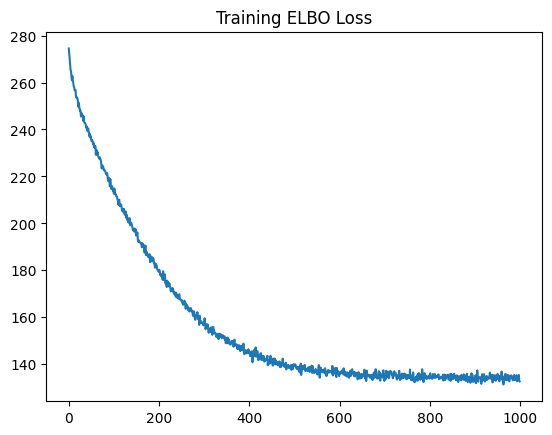

In [26]:
plt.plot(losses_1)
plt.title("Training ELBO Loss")
plt.show()

### Evaluation and results

In this last part of the notebook, we generate 500 Monte Carlo samples from the trained network to show uncertainty in the estimates of survival probabilities. To this regard, the point estimate of the the base cumulative hazard $\hat H_0(t)$ is computed with the Breslow estimator.
Let $t_1, t_2, \dots, t_D$ denote the distinct death times and $d_i$ be
the number of deaths at time $t_i$. Let $$W(t_i)=\sum_{j: t_j\ge t_i}\exp(f(\bm w, \bm x_j)).$$
The typical estimator of the base cumulative hazard is 
$$\hat H_0(t)=\sum_{i: t_i\le t}\frac{d_i}{W(t_i)}$$
but we average it over $\bm w$.
The estimate of the base survival function $\hat S_0(t)$ is then $\exp(-\hat H_0(t))$.

In [22]:
from lifelines.utils import concordance_index

In [23]:
from helpers import get_riskset
riskset = get_riskset(time) # time.view(-1, 1) <= time.repeat(len(time), 1)
train_riskset = get_riskset(time[train_data.indices])
test_riskset = get_riskset(time[test_data.indices])
test_riskset

tensor([[ True, False, False,  ..., False, False, False],
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True, False,  True,  ..., False, False, False],
        ...,
        [ True, False,  True,  ...,  True,  True,  True],
        [ True, False,  True,  ..., False,  True,  True],
        [ True, False,  True,  ..., False, False,  True]])

In [24]:
print("─" * 60)
print(" Concordance index evaluation for each topology")
print("─" * 60)

results_cindex = {}     # Dictionary to store all results

for i in range(len(topologies)):

    # Retrieve the correct model from global scope
    current_model = globals()[f"bnn_{i}"]
    current_model.eval()
    
    S = 500
    
    # Computation on test set
    test_samples = torch.zeros(len(test_data), S)
    for j in range(S):
        test_samples[:, j] = current_model(design_matrix[test_data.indices]).view(-1)

    # Extract metrics
    test_f_mean_np = test_samples.mean(dim=1).detach().numpy()
    test_time_np   = time[test_data.indices].detach().numpy()
    test_delta_np  = delta[test_data.indices].detach().numpy()

    # Compute and store C-index
    current_cindex = concordance_index(test_time_np, -test_f_mean_np, test_delta_np)
    results_cindex[f"bnn_{i}"] = current_cindex

    print(f"Model [bnn_{i}] done | Test Concordance Index: {current_cindex:.4f}")

────────────────────────────────────────────────────────────
 Concordance index evaluation for each topology
────────────────────────────────────────────────────────────
Model [bnn_0] done | Test Concordance Index: 0.6972
Model [bnn_1] done | Test Concordance Index: 0.7109
Model [bnn_2] done | Test Concordance Index: 0.7003
Model [bnn_3] done | Test Concordance Index: 0.7023
Model [bnn_4] done | Test Concordance Index: 0.6986
Model [bnn_5] done | Test Concordance Index: 0.6950
Model [bnn_6] done | Test Concordance Index: 0.6896
Model [bnn_7] done | Test Concordance Index: 0.6819
Model [bnn_8] done | Test Concordance Index: 0.6869


In [25]:
# Final ranking
print("─" * 60)
print(" Final models ranking:")
print("─" * 60)
for model_name, score in sorted(results_cindex.items(), key=lambda item: item[1], reverse=True):
    print(f"{model_name}: C-Index = {score:.4f}")

────────────────────────────────────────────────────────────
 Final models ranking:
────────────────────────────────────────────────────────────
bnn_1: C-Index = 0.7109
bnn_3: C-Index = 0.7023
bnn_2: C-Index = 0.7003
bnn_4: C-Index = 0.6986
bnn_0: C-Index = 0.6972
bnn_5: C-Index = 0.6950
bnn_6: C-Index = 0.6896
bnn_8: C-Index = 0.6869
bnn_7: C-Index = 0.6819


Once the best-performing architecture has been identified through the topology search, the selected model is retrained from scratch on the combined training and validation set. By folding the validation data back into the training pool, the model has access to a larger portion of the available data during the final fit, which may translate into an improvement in the test-set C-index. 

In [27]:
# Identify the best topology from validation results
best_model = max(results_cindex, key=results_cindex.get)
best_idx = int(best_model.split('_')[1])
best_topo = topologies[best_idx]
print(f"Best topology: {best_model} {best_topo} (C-index = {results_cindex[best_model]:.4f})")

# Combine training and validation indices
train_val_indices = train_data.indices + val_data.indices
train_val_dataset = torch.utils.data.Subset(dataset, train_val_indices)
train_val_loader = DataLoader(train_val_dataset, batch_size=128, generator=generator, shuffle=True)

# Retrain the best model on train + validation
bnn_retrain = BayesianMLP(*best_topo, 1, prior_sigma=1.0)
optimizer_final = optim.Adam(bnn_retrain.parameters(), lr=0.001)
losses_final = train(bnn_retrain, train_val_loader, optimizer_final, n_epochs=1000)
print("Retraining complete")

Best topology: bnn_1 (24, 32) (C-index = 0.7109)
Epoch     0, Average loss 258.674 (of which 120.883 KL))L)
Epoch   250, Average loss 158.680 (of which 34.597 KL)L)))
Epoch   500, Average loss 137.882 (of which 12.561 KL))L)
Epoch   750, Average loss 134.421 (of which 9.823 KL)L)L)
Retraining completee loss 132.886 (of which 9.417 KL)L)))


In [28]:
bnn_retrain.eval()
S = 500
final_samples = torch.zeros(len(test_data), S)
for j in range(S):
    final_samples[:, j] = bnn_retrain(design_matrix[test_data.indices]).view(-1)

final_test_mean = final_samples.mean(dim=1).detach().numpy()
test_time_np = time[test_data.indices].detach().numpy()
test_delta_np = delta[test_data.indices].detach().numpy()

final_cindex = concordance_index(test_time_np, -final_test_mean, test_delta_np)
print(f'C-index before retraining ({best_model}): {results_cindex[best_model]:.4f}')
print(f'C-index after retraining on train + val:{final_cindex:.4f}')

C-index before retraining (bnn_1): 0.7109
C-index after retraining on train + val:0.7161


The concordance index is defined as $$\text{C-index}=\mathbb P(M_j>M_i|T_j>T_i)$$
where $M_j$ denotes a score, that can be a predicted median time, or some monotonically related quantity (e.g., the probability of survive after a certain time). For a proportional hazards model, this metric is time-independent and it is sufficient to plug the negative of the output of the neural network (the higher the output, the lower the survival function), possibly averaged by the mean, hpd or median. Of course, it keeps into account also censoring.

The best architecture found during the topology search (bnn_1) achieved a concordance index of 0.711 on the test set, already slightly above the 0.71 of the classical Cox model reported in `EDA_and_CoxModel.ipynb`. After retraining on the combined training and validation data, the C-index further improved to 0.716, confirming that the additional data was beneficial. These results suggest that the Bayesian Cox model is competitive with its classical counterpart, while also providing uncertainty quantification on the survival estimates.

In [29]:
samples = torch.zeros(len(train_data), S)
for j in range(S):
    samples[:,j] = bnn_retrain(design_matrix[train_data.indices]).view(-1)

W = torch.zeros_like(samples)
for j in range(S):
    W[:, j] = (train_riskset * torch.exp(samples[:,j].repeat(len(samples[:,j]), 1))).sum(dim=1)

Wm = W.mean(dim=1)


In [30]:
cumhaz_0 = lambda t: (delta[train_data.indices] * (1/Wm) * (time[train_data.indices] < t.view(-1, 1))).sum(dim=1)
cumhaz_0(torch.tensor([500, 1000, 1500, 2000]))

tensor([0.0605, 0.1713, 0.1835, 0.1835], grad_fn=<SumBackward1>)

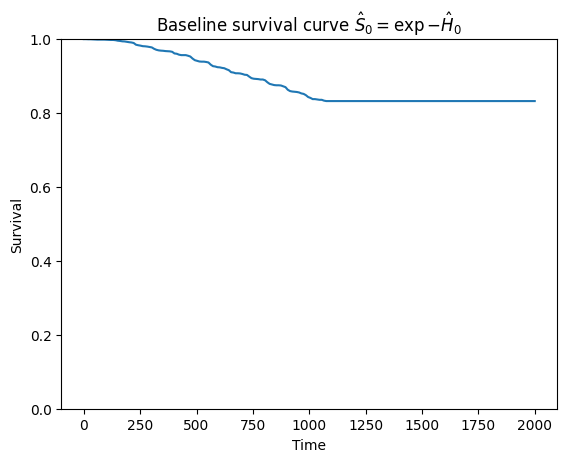

In [31]:
tt = torch.linspace(0, 2000, 200)
surv = torch.exp(-cumhaz_0(tt))
plt.plot(tt.detach().numpy(), surv.detach().numpy())
plt.ylim((0, 1))
plt.xlabel('Time')
plt.ylabel('Survival')
plt.title(r'Baseline survival curve $\hat S_0=\exp{-\hat H_0}$')
plt.show()

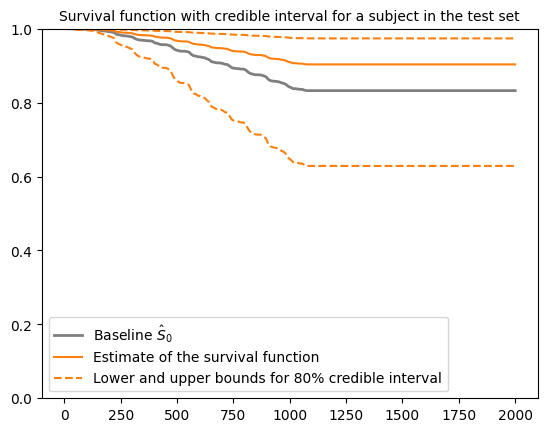

In [32]:
tt_np = tt.detach().numpy()
surv_np = surv.detach().numpy()
pct10, pct50, pct90 = test_samples[31,:].quantile(torch.tensor([0.1, 0.5, 0.9]))
plt.plot(tt_np, surv_np, c='black', alpha=0.5, linewidth=2, label=r"Baseline $\hat S_0$")
plt.plot(tt_np, surv_np**np.exp(pct50.item()), c='tab:orange', label="Estimate of the survival function")
plt.plot(tt_np, surv_np**np.exp(pct10.item()), c='tab:orange', linestyle='--', 
         label="Lower and upper bounds for 80% credible interval")
plt.plot(tt_np, surv_np**np.exp(pct90.item()), c='tab:orange', linestyle='--')
plt.ylim(0., 1.)
plt.legend(loc='lower left')
plt.title('Survival function with credible interval for a subject in the test set', fontdict={'size': 10})
plt.show()


The plot above depicts the survival curve for a suject with the following characteristics:

In [33]:
aids.iloc[test_data.indices[31]]

time       1120.0
trt           2.0
age          37.0
wtkg         63.6
hemo          0.0
homo          0.0
drugs         1.0
karnof       90.0
oprior        0.0
z30           0.0
zprior        1.0
preanti       0.0
race          1.0
gender        1.0
str2          0.0
strat         1.0
symptom       0.0
treat         1.0
offtrt        0.0
cd40        263.0
cd420       374.0
cd80        677.0
cd820      1106.0
cid           0.0
Name: 976, dtype: float64

<!--bibtex

@Article{PER-GRA:2007,
  Author    = {P\'erez, Fernando and Granger, Brian E.},
  Title     = {{IP}ython: a System for Interactive Scientific Computing},
  Journal   = {Computing in Science and Engineering},
  Volume    = {9},
  Number    = {3},
  Pages     = {21--29},
  month     = may,
  year      = 2007,
  url       = "http://ipython.org",
  ISSN      = "1521-9615",
  doi       = {10.1109/MCSE.2007.53},
  publisher = {IEEE Computer Society},
}

@article{Papa2007,
  author = {Papa, David A. and Markov, Igor L.},
  journal = {Approximation algorithms and metaheuristics},
  pages = {1--38},
  title = {{Hypergraph partitioning and clustering}},
  url = {http://www.podload.org/pubs/book/part\_survey.pdf},
  year = {2007}
}

-->

<!--bibtex

@Article{PER-GRA:2007,
  Author    = {P\'erez, Fernando and Granger, Brian E.},
  Title     = {{IP}ython: a System for Interactive Scientific Computing},
  Journal   = {Computing in Science and Engineering},
  Volume    = {9},
  Number    = {3},
  Pages     = {21--29},
  month     = may,
  year      = 2007,
  url       = "http://ipython.org",
  ISSN      = "1521-9615",
  doi       = {10.1109/MCSE.2007.53},
  publisher = {IEEE Computer Society},
}

@article{Papa2007,
  author = {Papa, David A. and Markov, Igor L.},
  journal = {Approximation algorithms and metaheuristics},
  pages = {1--38},
  title = {{Hypergraph partitioning and clustering}},
  url = {http://www.podload.org/pubs/book/part\_survey.pdf},
  year = {2007}
}

-->